In [1]:
list?

Init signature: list(iterable=(), /)
Docstring:     
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.
Type:           type
Subclasses:     _List, _HashedSeq, StackSummary, _Threads, ConvertingList, DeferredConfigList, _ymd, _Accumulator, SList, _ImmutableLineList, ...

In [3]:
import matplotlib.pyplot as plt
help(plt.plot)

Help on function plot in module matplotlib.pyplot:

plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.

    Call signatures::

        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

    The coordinates of the points or line nodes are given by *x*, *y*.

    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.

    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses

    You can use `.Line2D` properties as keyword arguments for more
    control on the appearance. Line pro

In [4]:
from platform import python_version
python_version()

'3.12.1'

In [5]:
def buggy_div(a,b):
    return a/b
buggy_div(3,0)

ZeroDivisionError: division by zero

In [7]:
#debugger
%pdb on
buggy_div(4,0)

Automatic pdb calling has been turned ON


ZeroDivisionError: division by zero

> /var/folders/10/vzvbs3px76sfj57d88__6yjc0000gn/T/ipykernel_90935/283093767.py(2)buggy_div()
      1 def buggy_div(a,b):
----> 2     return a/b
      3 buggy_div(3,0)



ipdb>  q


### Problem 2

For the first term of the conditional variance expression of the CIR process discussed in the class:

$$f(\kappa) = \frac{r_0 \sigma^2}{\kappa} (e^{-\kappa t} - e^{-2\kappa t})$$

* **Compute its condition number**, assuming $\kappa$ is the only variable.
* **Comment on whether the computation is stable** around $\kappa = 0$.
* **Implement a function** to compute the above expression which is numerically stable around $\kappa = 0$. A typical approach is to switch to an approximation when $\kappa$ is smaller than a threshold $h$.
* **Explain your choice of $h$**. Is the $h$ different for double or single precision calculation?


### Solution
We can use formula $k(f) = \sum_i \left| \frac{x_i}{f} \frac{\partial f}{\partial x_i} \right|$ 
$$
k(f) = \frac{\kappa}{f(\kappa)}\frac{df(\kappa)}{d\kappa} = \frac{\kappa}{f(\kappa)} \left(-\frac{r_0 \sigma^2}{\kappa^2} ( e^{-\kappa t} - e^{-2\kappa t}) + \frac{r_0 \sigma^2}{\kappa} (-t e^{-\kappa t} + 2te^{-2\kappa t}) \right) = \frac{\kappa}{( e^{-\kappa t} - e^{-2\kappa t})} \left(-\frac{1}{\kappa} ( e^{-\kappa t} - e^{-2\kappa t}) + (-t e^{-\kappa t} + 2te^{-2\kappa t}) \right) = \frac{\kappa(-t + 2te^{-\kappa t})}{( 1 - e^{-\kappa t})} -1
$$

$$
k(f) = \left| {\frac{-t\kappa(1-2e^{-\kappa t})}{(1-e^{-\kappa t})}} -1 \right|\approx \left|1-1\right|=0 \text{ as } \kappa \to 0
$$
Conclusion: The problem is well-posed near $\kappa = 0$ because the condition number is small (approaching 0). A small relative error in $\kappa$ does not explode into a large relative error in $f(\kappa)$.

he threshold $h$ is chosen where the Truncation Error of the Taylor series roughly equals the Rounding Error of the machine.
* Double Precision (64-bit): Machine epsilon $\epsilon_m \approx 10^{-16}$. We typically choose $h \approx 10^{-8}$.
* Single Precision (32-bit): Machine epsilon $\epsilon_m \approx 10^{-7}$. We need a much larger $h \approx 10^{-4}$

In [15]:
import numpy as np

def cir_variance_term(kappa, t, r0, sigma, precision='double'):
    h = 1e-8 if precision == 'double' else 1e-4
    if np.abs(kappa) < h:
        # Taylor expansion: r0 * sigma^2 * (t - 1.5*kappa*t^2 + (7/6)*kappa^2*t^3)
        return r0 * sigma**2 * (t - 1.5 * kappa * t**2 + (7/6) * (kappa**2) * (t**3))
    else:
        # Direct formula
        return (r0 * sigma**2 / kappa) * (np.exp(-kappa * t) - np.exp(-2 * kappa * t))
print(f"Double; Stable result at kappa=1e-15: {cir_variance_term(1e-8, 1.0, 0.05, 0.2)}")
print(f"Double; Stable result at kappa=1e-17: {cir_variance_term(1e-9, 1.0, 0.05, 0.2)}")
print(f"Stable result at kappa=1e-15: {cir_variance_term(1e-8, 1.0, 0.05, 0.2, 'single')}")
print(f"Stable result at kappa=1e-17: {cir_variance_term(1e-9, 1.0, 0.05, 0.2, 'single')}")

Double; Stable result at kappa=1e-15: 0.001999999965640598
Double; Stable result at kappa=1e-17: 0.0019999999970000005
Stable result at kappa=1e-15: 0.0019999999700000006
Stable result at kappa=1e-17: 0.0019999999970000005


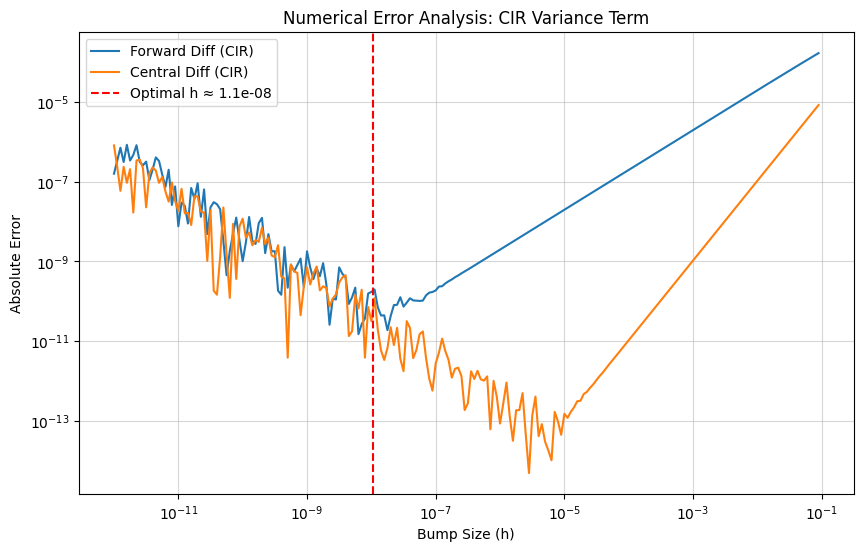

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the CIR process
R0, SIGMA, T = 0.05, 0.2, 1.0

# The function we are testing: f(kappa)
# This is the term: (r0 * sigma^2 / kappa) * (exp(-kappa*t) - exp(-2*kappa*t))
def target_function(kappa):
    # Using a high-precision calculation or assuming kappa is large enough for the 'exact' baseline
    return (R0 * SIGMA**2 / kappa) * (np.exp(-kappa * T) - np.exp(-2 * kappa * T))

# The analytical first derivative f'(kappa)
# Derived via the product rule as we discussed
def exact_first_derivative(kappa):
    term1 = -(R0 * SIGMA**2 / kappa**2) * (np.exp(-kappa * T) - np.exp(-2 * kappa * T))
    term2 = (R0 * SIGMA**2 / kappa) * (-T * np.exp(-kappa * T) + 2 * T * np.exp(-2 * kappa * T))
    return term1 + term2

# The analytical second derivative f''(kappa)
# Required to calculate the theoretical optimal h
def exact_second_derivative(kappa):
    # Simplified approximation near zero for the sake of the 'Optimal H' formula
    # Mathematically, f''(0) for this CIR term is -3 * r0 * sigma^2 * t^2
    return -3.0 * R0 * SIGMA**2 * T**2

# --- Numerical Analysis ---

x_point = 0.1 # Testing at kappa = 0.1
machine_precision = 1e-16 

# Wide range of bump sizes (h)
bump_sizes = 10.**np.arange(-12.0, -1.0, 0.05)

# Forward Difference
forward_diff = [(target_function(x_point + h) - target_function(x_point)) / h 
                for h in bump_sizes]

# Central Difference
central_diff = [0.5 * (target_function(x_point + h) - target_function(x_point - h)) / h 
                for h in bump_sizes]

# Errors
error_forward = np.abs(forward_diff - exact_first_derivative(x_point))
error_central = np.abs(central_diff - exact_first_derivative(x_point))

# Theoretical Optimal H for Forward Difference
optimal_h = np.sqrt(4.0 * np.abs(target_function(x_point)) * machine_precision / np.abs(exact_second_derivative(x_point)))

# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(bump_sizes, error_forward, label="Forward Diff (CIR)")
plt.loglog(bump_sizes, error_central, label="Central Diff (CIR)")
plt.axvline(x=optimal_h, color='r', linestyle='--', label=f"Optimal h ≈ {optimal_h:.1e}")

plt.title("Numerical Error Analysis: CIR Variance Term")
plt.xlabel("Bump Size (h)")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

### Problem 3

* **Implement a matrix product function** using hand-coded loops in Python. Please feel free to use NumPy array and NumPy vector multiplications, but obviously you should not just call NumPy matrix multiplication.
* **Compare the speed** of your implementation to the NumPy matrix product version.
* **Plot the difference** in computational time with the size of the matrix.

**Hint:**

* `%timeit` is a useful timing tool in IPython, or you can use the `time.clock()` function.
* NumPy has two ways of representing matrices: one is an array of arrays, and another is the matrix type. For array types, the matrix production is `a.dot(b)`; for the matrix type, the matrix production is `a * b`. We recommend you stick with the **array type** to avoid any potential confusion.
* The `a * b` operation on an **array type** is element-wise multiplication. A common mistake is to use `a * b` for matrix production on an array type. Please see the following code section as an example.
* `numpy.allclose` is a useful function to compare floating-point calculation results.

In [19]:
import numpy as np
u = np.arange(100,500,5)
v = np.arange(100,500,5)

In [22]:
%pdb off

Automatic pdb calling has been turned OFF


In [23]:
result = v.dot(u)
result

np.int64(8147000)

In [24]:
# Manual 
def manual_vector_dot(v,u):
    if len(v)==len(u):
        res = 0
        for i in range(len(v)):
            res = res + v[i]*u[i]
        return res
    else:
        raise ValueError("Both vectors should be of equal length")

In [25]:
manual_vector_dot(v,u)

np.int64(8147000)

In [26]:
%timeit manual_vector_dot(v,u)

20.9 μs ± 107 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [27]:
%timeit v.dot(u)

927 ns ± 9.44 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


### Time unit
- $1ms = 10^{-3}s$
- $1\micro s = 10^{-6}s$
- $1ns = 10^{-9}s$

### plot difference in computation time with size of matrix

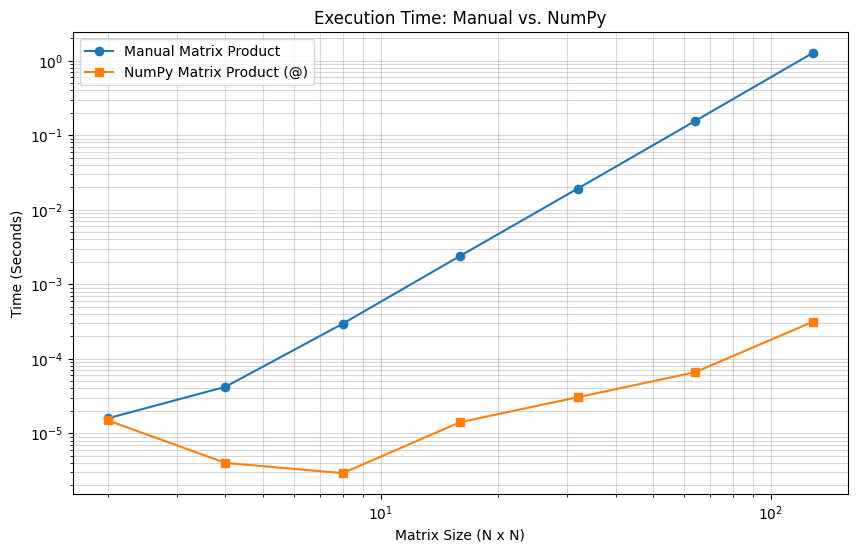

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

def manual_matrix_product(A, B):
    n, m = A.shape
    p = B.shape[1]
    C = np.zeros((n, p))
    for i in range(n):
        for j in range(p):
            for k in range(m):
                C[i, j] += A[i, k] * B[k, j]
    return C

# Benchmarking
sizes = [2, 4, 8, 16, 32, 64, 128]
manual_times = []
numpy_times = []

for s in sizes:
    A, B = np.random.rand(s, s), np.random.rand(s, s)
    
    # Time manual loop
    t0 = time.perf_counter()
    manual_matrix_product(A, B)
    manual_times.append(time.perf_counter() - t0)
    
    # Time NumPy optimized (@ or .dot())
    t0 = time.perf_counter()
    A @ B
    numpy_times.append(time.perf_counter() - t0)

# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(sizes, manual_times, 'o-', label='Manual Matrix Product')
plt.loglog(sizes, numpy_times, 's-', label='NumPy Matrix Product (@)')
plt.title('Execution Time: Manual vs. NumPy')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (Seconds)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()